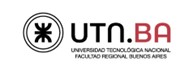

###**Trabajo Semanal 2**
**Teoria de los Circuitos 2**


Autor: Alan Nicolas Parizek


Profesor: Mariano Llamedo Soria  
Ayudante de TPs: David Moharos  
Jefe de TPs: César Fuoco  




#Imports

In [2]:
import sympy as sp
import numpy as np
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot

In [3]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

In [4]:
from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq
from pytc2.general import print_latex, a_equal_b_latex_s

#Desarrollo

###Desarrollo analítico

$$|T|^2 = \frac{1}{1 + s^{12}} \qquad \theta = \frac{(2k+1)\pi}{2n} \quad ; \quad \theta = \frac{(2k+1)\pi}{12}$$

$$Q_1 = \frac{1}{2\cos(\frac{11}{12}\pi)} = 0,518$$

$$Q_2 = \frac{1}{2\cos(\frac{3}{4}\pi)} = \frac{\sqrt{2}}{2} \approx 0,71$$

$$Q_3 = \frac{1}{2\cos(\frac{7}{12}\pi)} = 1,93$$

---

$$T(s) = T_1(s) \cdot T_2(s) \cdot T_3(s)$$

$$T(s) = \frac{\omega_{p1}^2}{s^2 + \frac{\omega_{01}s}{Q} + \omega_{01}^2} \cdot \frac{\omega_{p2}^2}{s^2 + \frac{\omega_{02}s}{Q} + \omega_{02}^2} \cdot \frac{\omega_{p3}^2}{s^2 + \frac{\omega_{03}s}{Q} + \omega_{03}^2}$$

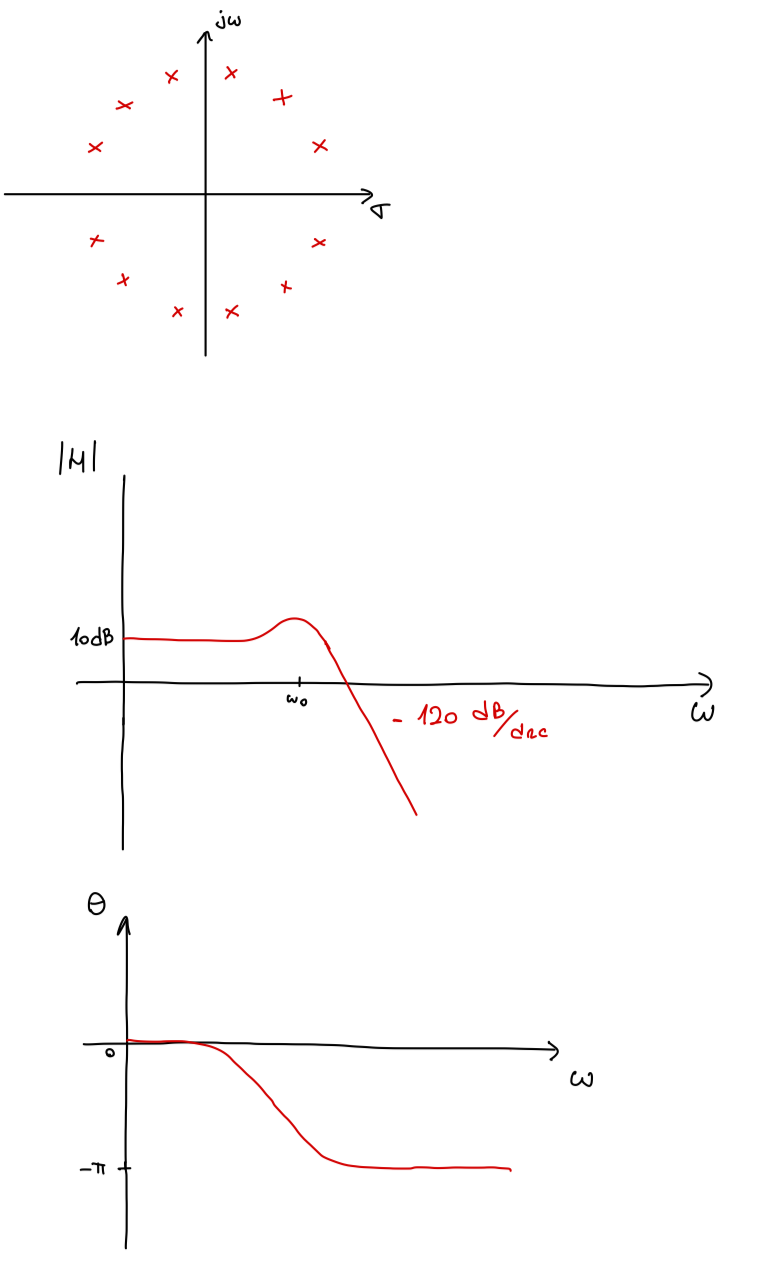

Analisis hecho para la red normalizada, con las 3 Wo=1

A continuación, se calculan las transferencias y valores de componentes de cada SOS:

Sallen-Key

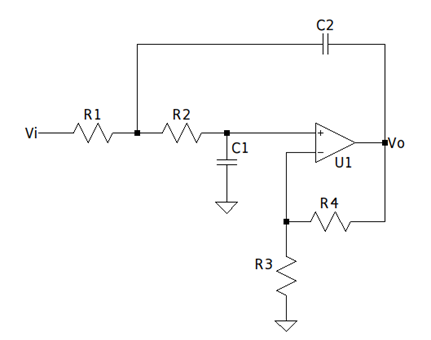

$$V_x(G_1 + G_2 + sC_2) - V_y G_2 - V_i G_1 - V_o sC_2 = 0$$

$$V_y(G_2 + sC_1) - V_x G_2 = 0$$

$$V_y(G_a + G_b) - V_o G_b = 0$$

---

$$H(s) = \frac{\frac{G_1 G_2 (G_a + G_b)}{C_1 C_2 G_b}}{s^2 + s \frac{(C_1 G_1 G_b - C_1 G_2 G_a + C_2 G_b G_2)}{C_1 C_2 G_b} + \frac{G_1 G_2}{C_1 C_2}}$$

Elijo: $C_1 = C_2$ ; $R_1 = R_2 = R_a$

$$H(s) = \frac{\frac{G_a^2 (G_a + G_b)}{C^2 G_b}}{s^2 + s \frac{G_a G_b - G_a^2 + G_a G_b}{C G_b} + \frac{G_a^2}{C^2}}$$

Normalizo con $\Omega_y = G_1$ y $\Omega_w = \frac{1}{C^2}$

---

$$H(s) = \frac{\frac{1 + G_b'}{G_b'}}{s^2 + s \frac{1}{G_b'} + 1}$$

$$G_b' = Q$$

Si: $G_b' = 0,51$:

$$A_1 = \frac{1 + G_b'}{G_b'} = 2,9305$$

In [ ]:
VI, VX, VY, VO = sp.symbols("VI, VX, VY, VO")
G1, G2, GA, GB, C1, C2 = sp.symbols("G1, G2, GA, GB, C1, C2")
G, C, wt, w0 = sp.symbols("G, C, wt, w0", real = True, posistive = True)

eq1 =   VX * (G1 + G2 + s*C1) - VY * G2 - VI * G1 - VO * s*C1
eq2 = VY * (G2 + s*C2) - VX * G2
eq3 = VY * (GA + GB) - VO * GB


sol = sp.solve([eq1, eq2, eq3], (VX, VY, VO))

H = sp.simplify(sol[VO]/ VI)

print_latex(a_equal_b_latex_s('H(s)',H))


<IPython.core.display.Math object>

KHN

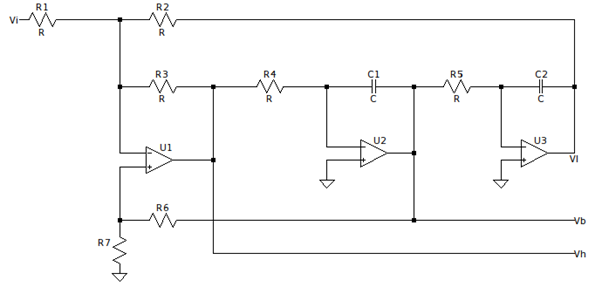

$$V_1(G_1 + G_2 + G_3) - V_2 G_3 - V_i G_1 - V_o G_2 = 0$$

$$V_1(G_6 + G_7) - V_4 G_6 = 0$$

$$V_3(G_4 + sC_1) - V_2 G_4 - V_4 sC_1 = 0$$

$$V_3(G_5 + sC_2) - V_4 G_5 - V_o sC_2 = 0$$

---

$$H(s) = \frac{-\frac{G_1 G_4 G_5}{C_1 C_2 G_3}}{s^2 + s \frac{G_6 (G_1 + G_2 + G_3)}{C_1 G_3 (G_6 + G_7)} + \frac{G_2 G_4 G_5}{C_1 C_2 G_3}}$$

Si $G_2 = G_3 = G_4 = G_5 = G_6 = G_7$ y

Normalizo con $Y_\Omega = G_2$ y $\Omega_w = \frac{1}{C_1 C_2}$ :

$$H(s) = -\frac{G_1'}{s^2 + s \frac{G_1' + 2}{2C_1'} + 1}$$

$$\frac{G_1' + 2}{2C_1'} = \frac{\omega_0}{Q} \rightarrow Q = \frac{2C_1'}{G_1' + 2}$$

---

Para tener 10dB de ganancia:

$$A_1 = 2,9305 \quad ; \quad A_3 = 1 \quad ; \quad A_v = 10\text{dB} = 3,1623$$

$$A_2 = 1,079 = G_1'$$

$$C_1' = \frac{1,079 + 2}{2} Q$$

In [ ]:
#KHN

VI, V1, V2, V3, V4, V5, VO =  sp.symbols("VI, V1, V2, V3, V4, V5 VO")
G1, G2, G3, G4, G5, G6, G7, C1, C2 = sp.symbols("G1, G2, G3, G4, G5, G6, G7, C1, C2")
G, C, wt, w0 = sp.symbols("G, C, wt, w0", real = True, posistive = True)

eq1 = V1 * (G1 + G2 + G3) - VI * G1 - VO * G2 - V2 * G3
eq2 = V1 * (G6 + G7) - V4 * G6
eq3 = V3 * (G4 + s*C1) - V2 * G4 - V4 * s*C1
eq4 = V5 * (G5 + s*C2) - V4 * G5 - VO * s*C2
eq5 = V3
eq6 = V5

sol = sp.solve([eq1, eq2, eq3, eq4, eq5, eq6], (V1, V2, V3, V4, V5, VO), dict=True)

H = sp.simplify(sol[0][VO] / VI)

print_latex(a_equal_b_latex_s('H(s)',H))

<IPython.core.display.Math object>

MFB

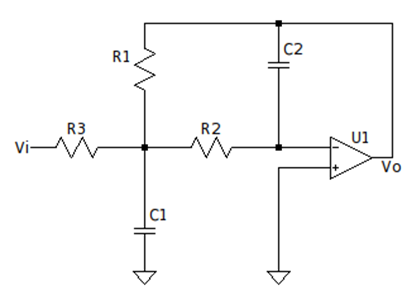

$$
V_A (G_1 + G_2 + G_3 + s C_1) - V_i G_3 - V_b G_2 - V_o G_1 = 0
$$

$$
V_b (G_2 + s C_1) - V_A G_2 - V_o s C_2 = 0
$$

$$
V_b = 0
$$

---

$$
H(s) = - \frac{\dfrac{G_2 G_3}{C_1 C_2}}
{s^2 + s \dfrac{G_1 + G_2 + G_3}{C_2} + \dfrac{G_1 G_2}{C_1 C_2}}
$$

$$
\text{Si: } G_1 = G_2 = G_3
$$

$$
\text{Normalizo con: } S_y = G_1 \quad \text{y} \quad \Omega_w = \frac{1}{C_1 C_2}
$$

$$
H'(s) = - \frac{1}{s^2 + s \dfrac{3}{C_2} + 1}
$$

---

$$
C_1 = \frac{1}{C_2}
\quad ; \quad
\frac{3}{C_2} = \frac{1}{Q}
\quad \Rightarrow \quad
C_2 = 3Q
$$

$$
A_3 = 1
$$

In [5]:
#MFB
VI, VX, VY, VO = sp.symbols("VI, VX, VY, VO")
G1, G2, G3, C1, C2 = sp.symbols("G1, G2, G3, C1, C2")
G, C, wt, w0 = sp.symbols("G, C, wt, w0", real = True, posistive = True)

eq1 = VX*(G1 + G2 + G3 +  s*C1) - VI*G3 - VY*G2 - VO*G1

eq2 = VY*(G2 + s*C2) - VX*G2 - VO*s*C2

eq3 = VY

sol = sp.solve([eq1, eq2, eq3], (VX, VY, VO))

H = sp.simplify(sol[VO]/ VI)

print_latex(a_equal_b_latex_s('H(s)',H))

<IPython.core.display.Math object>

###Simulacion Numerica

La pendiente en la zona de rechazo es: -120.00 dB/dec


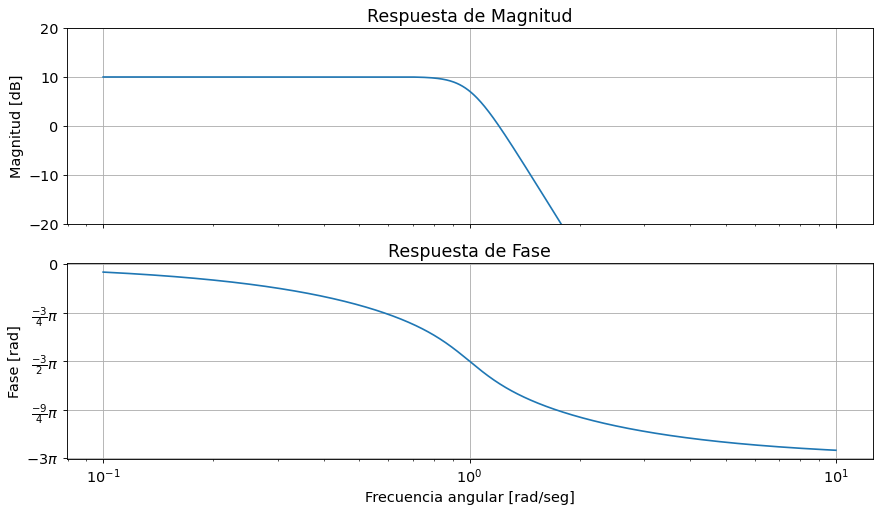

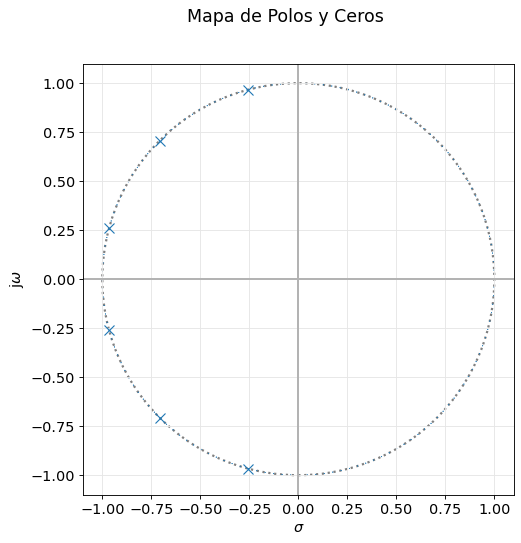

In [21]:
#Sallen-Key

Gb = 0.518
num1 = np.array([(1 + Gb)/Gb])
den1 = np.array([1, 1/Gb, 1])

T1 = sig.TransferFunction( num1, den1 )

#KHN

Q= 0.707
G1= 1.079
C1= ((G1+2)*Q)/2
num2= np.array([-G1])
den2 = np.array([1, (G1 + 2)/(2*C1), +1])

T2 = sig.TransferFunction( num2, den2 )

#MFB

Q = 1.96
C2 = 3*Q
num3= np.array([-1])
den3 = np.array([1, 3/C2, 1])

T3 = sig.TransferFunction( num3, den3 )

num = np.polymul(np.polymul(num1, num2), num3)
den = np.polymul(np.polymul(den1, den2), den3)

TF = sig.TransferFunction(num, den)

_, axes_hdl = bodePlot(TF)

plt.sca(axes_hdl[0])
plt.ylim(-20, 20)
pzmap(TF)

w, mag, phase = sig.bode(TF)
w1, w2 = w[-2], w[-1]
m1, m2 = mag[-2], mag[-1]

pendiente = (m2 - m1) / np.log10(w2 / w1)

print(f"La pendiente en la zona de rechazo es: {pendiente:.2f} dB/dec")

Se puede notar la ganancia de 10dB en la banda de paso y la caida de 120dB/dec. Tambien se puede ver que las 3 Wo estan en w=1, esto se debe a la normalizacion. Una vez desnormalizada la red, tendrá 3 frecuencias distintas, ya que dependen de componentes independientes.

###Simulacion Circuital

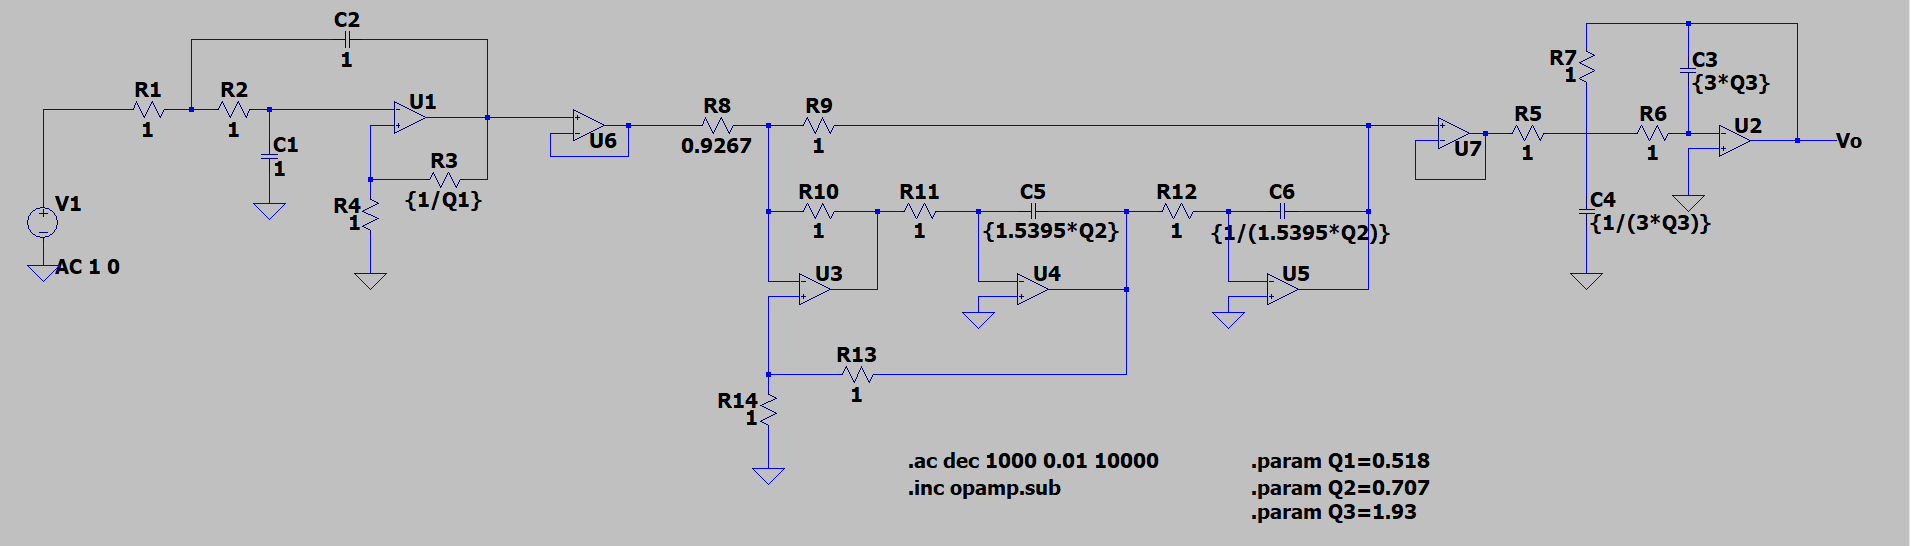

Circuito Normalizado

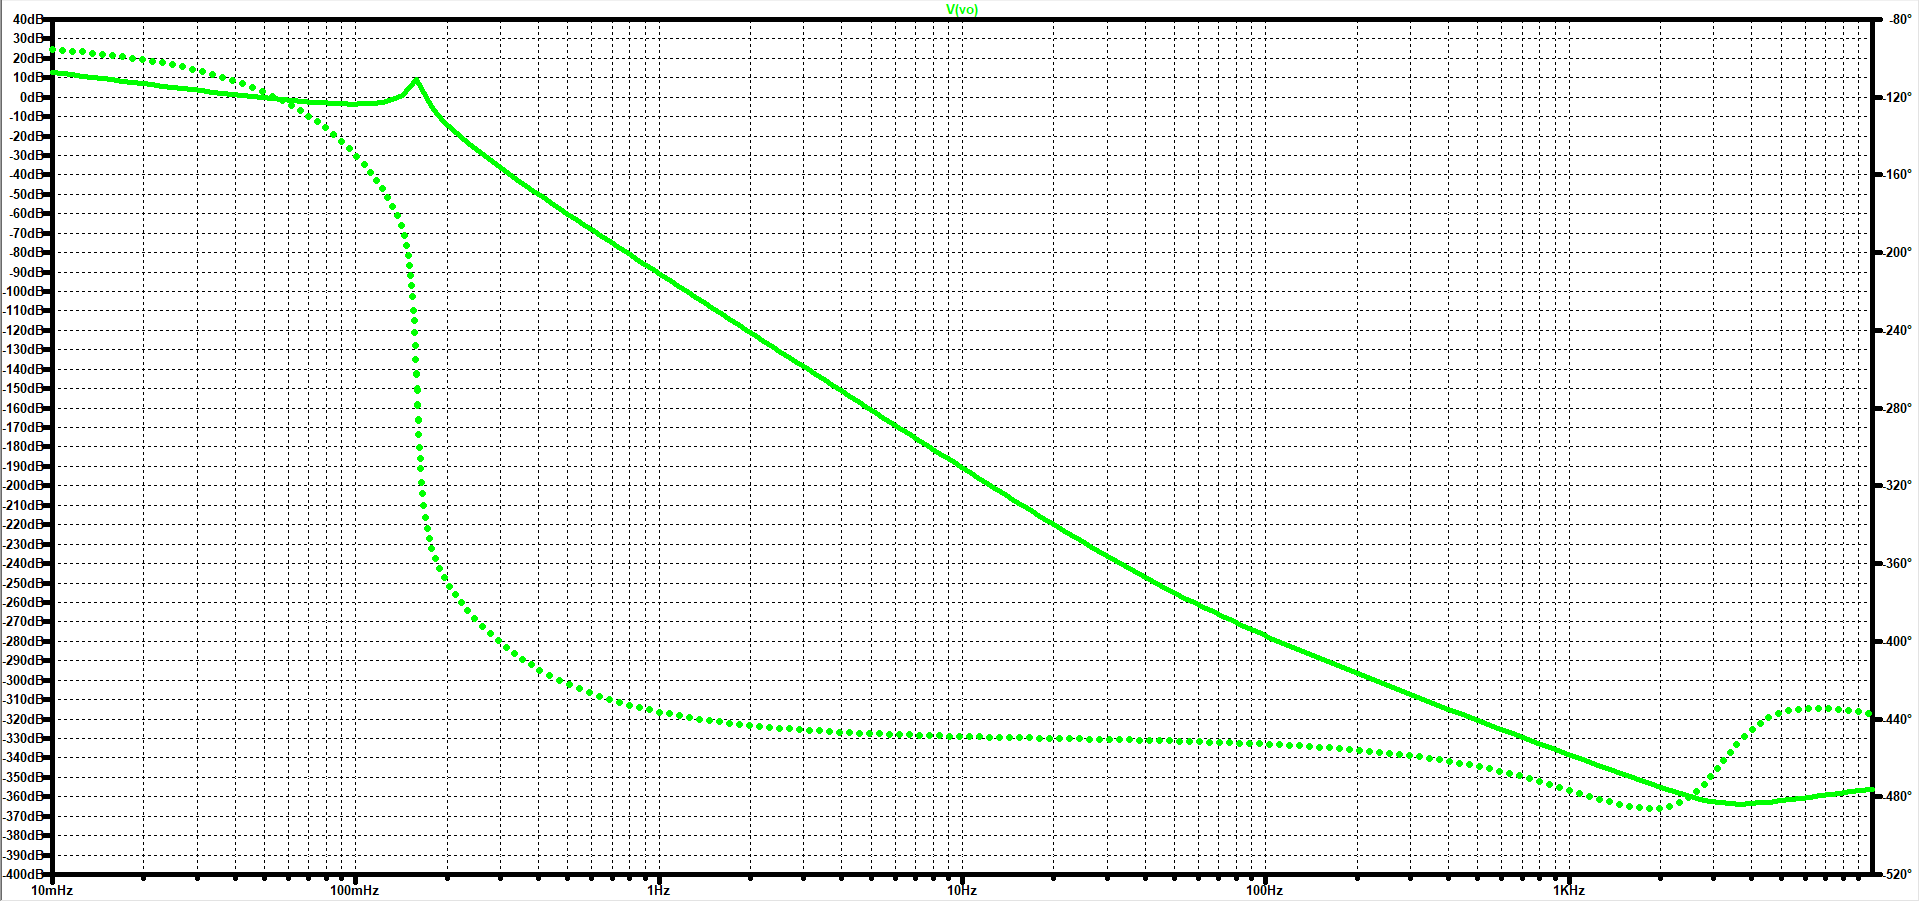

Amplitud y Fase de la Transferencia del sistema